In [1]:
import sys, os
# os.environ['PATH']='/projects/bdne/spandey3/tex/texlive/bin/x86_64-linux:'+ os.environ['PATH']
# os.environ['PYTHONPATH']='/projects/bdne/spandey3/tex/texlive/bin/x86_64-linux:'
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.98'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')

import matplotlib

import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = False
%load_ext autoreload
%autoreload 2
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
# pl.rc('font', family='DejaVu Sans')

%matplotlib inline
%load_ext autoreload
%autoreload 2



/tmp/ipykernel_4035096/3824677826.py:9: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


1 1
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
abs_path_src


'/projects/bdne/spandey3/new_godmax/GODMAX/src'

In [50]:
import yaml

def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

# yaml_file_path = '/mnt/home/spandey/ceph/GODMAX/param_files/params_default.yaml'
yaml_file_path = abs_path_params + '/params_default.yaml'
data = read_yaml(yaml_file_path)
sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(data)


#   rmin: 0.005
#   rmax: 8.0
#   nr: 18

#   zmin: 0.01
#   zmax: 1.6
#   nz: 18

#   lg10_Mmin: 11.5
#   lg10_Mmax: 15.5
#   nM: 18
halo_params_dict['rmin'] = 0.0005
halo_params_dict['rmax'] = 8.0
halo_params_dict['nr'] = 96
halo_params_dict['zmax'] = 2.0
halo_params_dict['nz'] = 64
halo_params_dict['lg10_Mmin'] = 12.0
halo_params_dict['lg10_Mmax'] = 16.0
halo_params_dict['nM'] = 64




In [51]:
from colossus.cosmology import cosmology as cosmology_colossus
from colossus.lss import mass_function
from colossus.halo import concentration
from colossus.halo import mass_defs
from colossus.lss import bias

# websky_cosmo = {'Omega_M': 0.31, 'Omega_B': 0.049, 'Omega_L': 0.69, 
                                #  'h': 0.68, 'sigma_8': 0.81, 'n_s':0.965}
params = {'w0':-1.0 ,'flat': True, 'H0': 69.0, 'Om0': 0.31, 'Ob0': 0.049, 'sigma8':0.81 ,'ns': 0.965}
cosmology_colossus.addCosmology('myCosmo', params)
cosmology_colossus.setCosmology('myCosmo')
cosmo_colossus = cosmology_colossus.setCosmology('myCosmo')





In [52]:
from godmax.get_B12_profile import Battaglia_12_16
import helpers.constants as constants
cosmo_params_dict = {'w0':-1.0 ,'flat': True, 'H0': 69.0, 'Om0': 0.31, 'Ob0': 0.049, 'sigma8':0.81 ,'ns': 0.965}
B12_test = Battaglia_12_16({'cosmo':cosmo_params_dict, 'init_power':True}, halo_params_dict)


mdef = '200c'
dndm_model = 'tinker08'
bias_model = 'tinker10'

dndlnM_mat = np.zeros((B12_test.nz,B12_test.nM))
bias_Mz_mat = np.zeros((B12_test.nz,B12_test.nM))

for jz in range(B12_test.nz):
    dndlnM_mat[jz,:] = mass_function.massFunction(B12_test.M_array, B12_test.z_array[jz],mdef=mdef, model=dndm_model,q_out='dndlnM')
    bias_Mz_mat[jz,:] = bias.haloBias(B12_test.M_array, model=bias_model, z=B12_test.z_array[jz], mdef=mdef)




### Measure $P_{hy} (k, z)$ with this profile:


In [53]:
from mcfitjax.cosmology_jax import xi2P
from godmax.base_class import get_vmapped_func, get_vmapped_func_warg
from jax import jit, vmap

xi2P_obj = (xi2P(B12_test.r_array, nx=B12_test.nr,lowring=True))
k_mcfit, uk_y = xi2P_obj(B12_test.y3d_mat, axis=0, extrap=False)
uk_y_tointp = jnp.array(uk_y)

@jit
def get_uk_from_interp_Pk(jz, jM):
    uk_val = uk_y_tointp[:, jz, jM]
    # Perform interpolation in log space for stability
    return jnp.exp(
        jnp.interp(
            jnp.log(B12_test.kPk_array), 
            jnp.log(k_mcfit), 
            jnp.log(jnp.clip(uk_val, 1e-30, jnp.inf))
        )
    )
vmapped_func = get_vmapped_func(get_uk_from_interp_Pk, 2)
uk_y = vmapped_func(jnp.arange(B12_test.nz), jnp.arange(B12_test.nM)).T

by_kz_mat = np.trapezoid(uk_y*dndlnM_mat*bias_Mz_mat, np.log(B12_test.M_array))



In [54]:
lgMmin_halo = 14.0
lgMmax_halo = 14.5
# zmin_halo = 0.2
# zmax_halo = 0.3

zmin_halo = 1.0
zmax_halo = 1.5

M_mat = np.repeat(B12_test.M_array[None,:], B12_test.nz, axis=0)
z_mat = np.repeat(B12_test.z_array[:, None], B12_test.nM, axis=1)
indsel = np.where((M_mat > 10**lgMmin_halo) & (M_mat < 10**lgMmax_halo) & (z_mat > zmin_halo) & (z_mat < zmax_halo))[0]

Ncen_mat = np.zeros_like(M_mat)
Ncen_mat[indsel] = 1

nbar_z = np.clip(np.trapezoid(Ncen_mat * dndlnM_mat, np.log(B12_test.M_array)), 1e-10, 1e10)

ukzM_halo = Ncen_mat[None,...]/nbar_z[None,:,None]
bkz_halo = np.trapezoid(ukzM_halo*dndlnM_mat*bias_Mz_mat, np.log(B12_test.M_array))

nz_interp = np.interp(B12_test.z_array_for_Cls, B12_test.z_array, nbar_z)
norm_val = np.trapezoid(nz_interp, x=B12_test.z_array_for_Cls)
nz_halos = nz_interp/norm_val



In [55]:
P_hy_1h = jnp.clip(jnp.array(np.trapezoid(ukzM_halo*uk_y*dndlnM_mat, np.log(B12_test.M_array))), 1e-30, 1e5)
P_hy_2h = jnp.clip(jnp.array(by_kz_mat * bkz_halo * B12_test.plin_kz_mat), 1e-30, 1e5)
P_hy_tot = jnp.array(P_hy_1h + P_hy_2h)


In [56]:
import interpax
import jax.scipy.integrate as jsi
def get_P_lz(jl, jz, Pk_mat):   
    ell = B12_test.ell_array[jl]
    chi_z = B12_test.chi_array[jz]
    k_ell = (ell + 0.5)/jnp.clip(chi_z, 1.0)
    Pkz_ell = jnp.exp(jnp.interp(jnp.log(k_ell), jnp.log(B12_test.kPk_array), jnp.log(Pk_mat[:,jz])))
    return Pkz_ell

def get_Cls(jl, logP_interp_obj):
    Pk = jnp.exp(logP_interp_obj(jnp.log(B12_test.ell_array[jl]), B12_test.z_array_for_Cls))
    fx = prefac_halos * prefac_y  * (B12_test.chi_array_for_Cls ** 2) * B12_test.dchi_dz_array_for_Cls * Pk
    return jsi.trapezoid(fx, x=B12_test.z_array_for_Cls) 

prefac_halos = jnp.array(nz_halos/ (B12_test.dchi_dz_array_for_Cls * B12_test.chi_array_for_Cls**2))
Wy_array = (1.0 / (1.0 + B12_test.z_array_for_Cls))
prefac_y = jnp.array(Wy_array / (B12_test.chi_array_for_Cls**2))




vmapped_func = get_vmapped_func_warg(get_P_lz, 2, 3)
P_hy_1h_lz_mat = vmapped_func(jnp.arange(B12_test.nell), jnp.arange(B12_test.nz), jnp.array(P_hy_1h)).T
logPkgylz_1h_2d_interp = interpax.Interpolator2D(jnp.log(B12_test.ell_array), B12_test.z_array, jnp.log(P_hy_1h_lz_mat), 
extrap=True)  
# vmapped_func = get_vmapped_func_warg(get_Cls, 1, 2)
vmapped_func_Cls = vmap(get_Cls, in_axes=(0, None))
Cl_hy_1h = vmapped_func_Cls(jnp.arange(B12_test.nell),logPkgylz_1h_2d_interp)


P_hy_2h_lz_mat = vmapped_func(jnp.arange(B12_test.nell), jnp.arange(B12_test.nz), jnp.array(P_hy_2h)).T
logPkgylz_2h_2d_interp = interpax.Interpolator2D(jnp.log(B12_test.ell_array), B12_test.z_array, jnp.log(P_hy_2h_lz_mat), 
extrap=True)     
Cl_hy_2h = vmapped_func_Cls(jnp.arange(B12_test.nell),logPkgylz_2h_2d_interp)




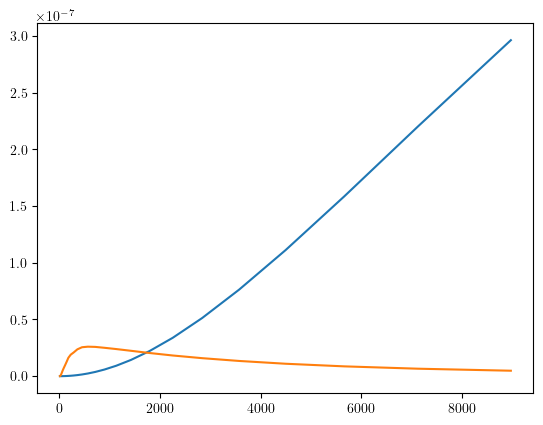

In [57]:
fac = (B12_test.ell_array)*(B12_test.ell_array + 1)/(2*np.pi)
pl.figure()
pl.plot(B12_test.ell_array, fac*Cl_hy_1h)
pl.plot(B12_test.ell_array, fac*Cl_hy_2h)
# pl.xscale('log')



In [58]:
from astropy.io import fits
# df = fits.open(abs_path_data + '/websky/halo_input_wM200c_zmax2p5_minM200m_noh_5e13.fits')
df = fits.open(abs_path_data + '/websky/halo_input_wM200c_zmax2p5_minM200m_noh_5e13.fits')
# df[1].header
ra_all = df[1].data['ra']
dec_all = df[1].data['dec']
z_all = df[1].data['z']
M200c_all = df[1].data['M200c_wh']
M200m_all = df[1].data['M200m_wh']
vlos_all = df[1].data['vrad']
# c200c_all = df[1].data['c200c']
# indsel = np.where((M200m_all > 6e13) & (M200m_all < 5e15) & (z_all<2.5))[0]
indsel = np.where((M200c_all > 10**lgMmin_halo) & (M200c_all < 10**lgMmax_halo) & (z_all>zmin_halo) & (z_all<zmax_halo))[0]
print(len(indsel), len(M200c_all))
ra_all = ra_all[indsel]
dec_all = dec_all[indsel]
z_all = z_all[indsel]
M200c_all = M200c_all[indsel]
vlos_all = vlos_all[indsel]

# len(np.where((z_all > zmin_halo) & (z_all < zmax_halo))[0]), len(np.where((z_all > 0.5) & (z_all < 1.0))[0]), len(np.where((z_all > 1.0) & (z_all < 2.5))[0])






62755 4349354


In [59]:
import healpy as hp
nside = 1024
maph   = np.zeros((hp.nside2npix(nside)))
pix = hp.ang2pix(nside, ra_all, dec_all, lonlat=True)
weight = 1. #1 for number density, array of size(x) for arbitrary
np.add.at(maph, pix, weight)
delta_h = maph/np.mean(maph) - 1



In [60]:
# df = pk.load(open(abs_path_data + '/websky/tSZ_sim_B12_testv6_nside_4096.pkl','rb'))
df = pk.load(open(abs_path_data + '/websky/tSZ_sim_B12_testv6_nside_1024_M200m_sel_5e13_5e15.pkl','rb'))
ymap_full = np.array(df['ymap_test'])
# ymap_ud = hp.ud_grade(ymap_full, nside)
# 





In [61]:
delta_h.shape, ymap_full.shape


((12582912,), (12582912,))

In [62]:
Cl_hy_websky = hp.anafast(delta_h, ymap_full)


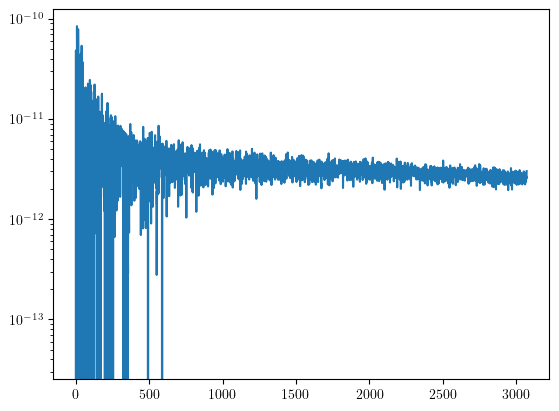

In [63]:
pl.figure()
pl.plot(np.arange(len(Cl_hy_websky)), Cl_hy_websky)
pl.yscale('log')



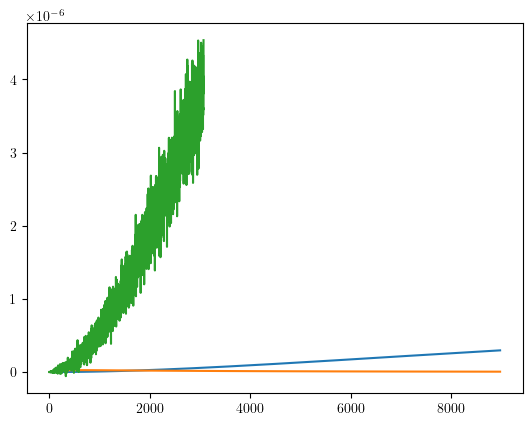

In [64]:
fac = (B12_test.ell_array)*(B12_test.ell_array + 1)/(2*np.pi)
pl.figure()
pl.plot(B12_test.ell_array, fac*Cl_hy_1h)
pl.plot(B12_test.ell_array, fac*Cl_hy_2h)

ell = np.arange(len(Cl_hy_websky))
fac2 = ell*(ell + 1)/(2*np.pi)
pl.plot(ell, fac2*Cl_hy_websky)

